# Nigerian Music scraped from Spotify - an analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/nigerian-songs.csv")
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              530 non-null    object 
 1   album             530 non-null    object 
 2   artist            530 non-null    object 
 3   artist_top_genre  530 non-null    object 
 4   release_date      530 non-null    int64  
 5   length            530 non-null    int64  
 6   popularity        530 non-null    int64  
 7   danceability      530 non-null    float64
 8   acousticness      530 non-null    float64
 9   energy            530 non-null    float64
 10  instrumentalness  530 non-null    float64
 11  liveness          530 non-null    float64
 12  loudness          530 non-null    float64
 13  speechiness       530 non-null    float64
 14  tempo             530 non-null    float64
 15  time_signature    530 non-null    int64  
dtypes: float64(8), int64(4), object(4)
memory us

In [3]:
df.isnull().sum()

name                0
album               0
artist              0
artist_top_genre    0
release_date        0
length              0
popularity          0
danceability        0
acousticness        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
time_signature      0
dtype: int64

In [4]:
df.describe()

,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
count,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,2015.390566,222298.169811,17.507547,0.741619,0.265412,0.760623,0.016305,0.147308,-4.953011,0.130748,116.487864,3.986792
std,3.131688,39696.822259,18.992212,0.117522,0.208342,0.148533,0.090321,0.123588,2.464186,0.092939,23.518601,0.333701
min,1998.000000,89488.000000,0.000000,0.255000,0.000665,0.111000,0.000000,0.028300,-19.362000,0.027800,61.695000,3.000000
25%,2014.000000,199305.000000,0.000000,0.681000,0.089525,0.669000,0.000000,0.075650,-6.298750,0.059100,102.961250,4.000000
50%,2016.000000,218509.000000,13.000000,0.761000,0.220500,0.784500,0.000004,0.103500,-4.558500,0.097950,112.714500,4.000000
75%,2017.000000,242098.500000,31.000000,0.829500,0.403000,0.875750,0.000234,0.164000,-3.331000,0.177000,125.039250,4.000000
max,2020.000000,511738.000000,73.000000,0.966000,0.954000,0.995000,0.910000,0.811000,0.582000,0.514000,206.007000,5.000000


In [8]:
import seaborn as sns

Text(0.5, 1.0, 'Top genres')

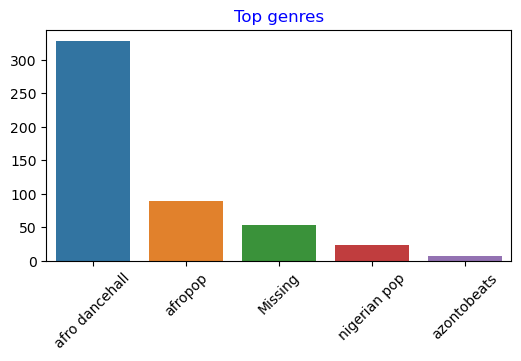

In [14]:
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(6,3))
sns.barplot(x=top[:5].index,y=top[:5].values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')


**Missing Values** are a lot in the count, we remove this.

Text(0.5, 1.0, 'Top genres')

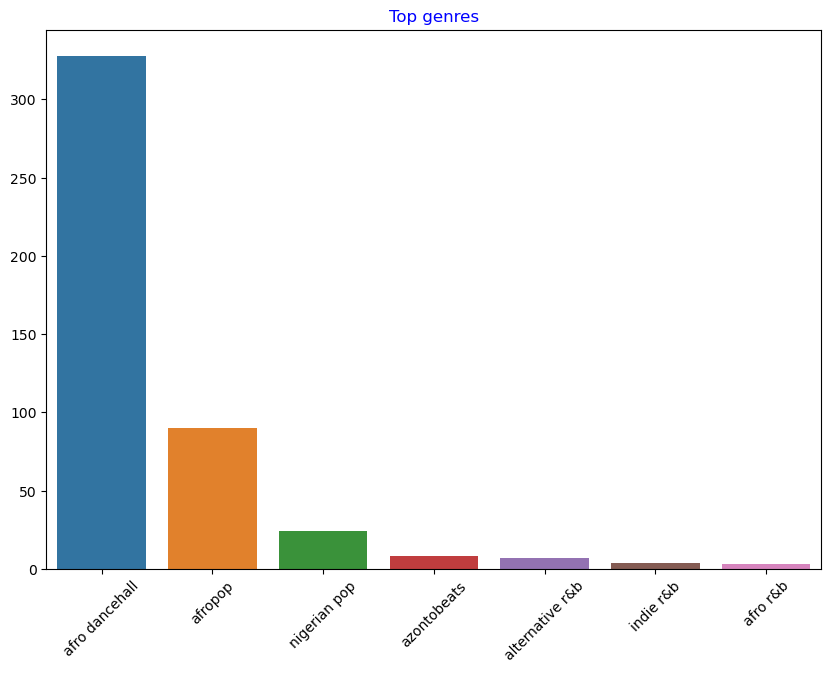

In [16]:
df = df[df['artist_top_genre'] != 'Missing']
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top[:7].index,y=top[:7].values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

## Preprocessing 

By far, the top three genres dominate this dataset. Let's concentrate on afro dancehall, afropop, and nigerian pop, additionally filter the dataset to remove anything with a 0 popularity value (meaning it was not classified with a popularity in the dataset and can be considered noise for our purposes)

Text(0.5, 1.0, 'Top genres')

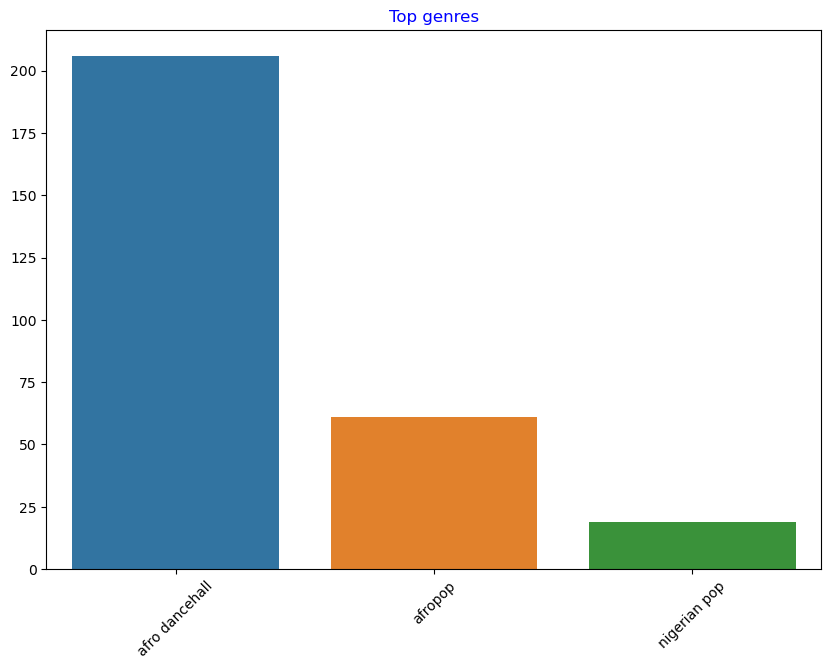

In [17]:
df = df[(df['artist_top_genre'] == 'afro dancehall') | (df['artist_top_genre'] == 'afropop') | (df['artist_top_genre'] == 'nigerian pop')]
df = df[(df['popularity'] > 0)]

top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

## Correlation

<AxesSubplot:>

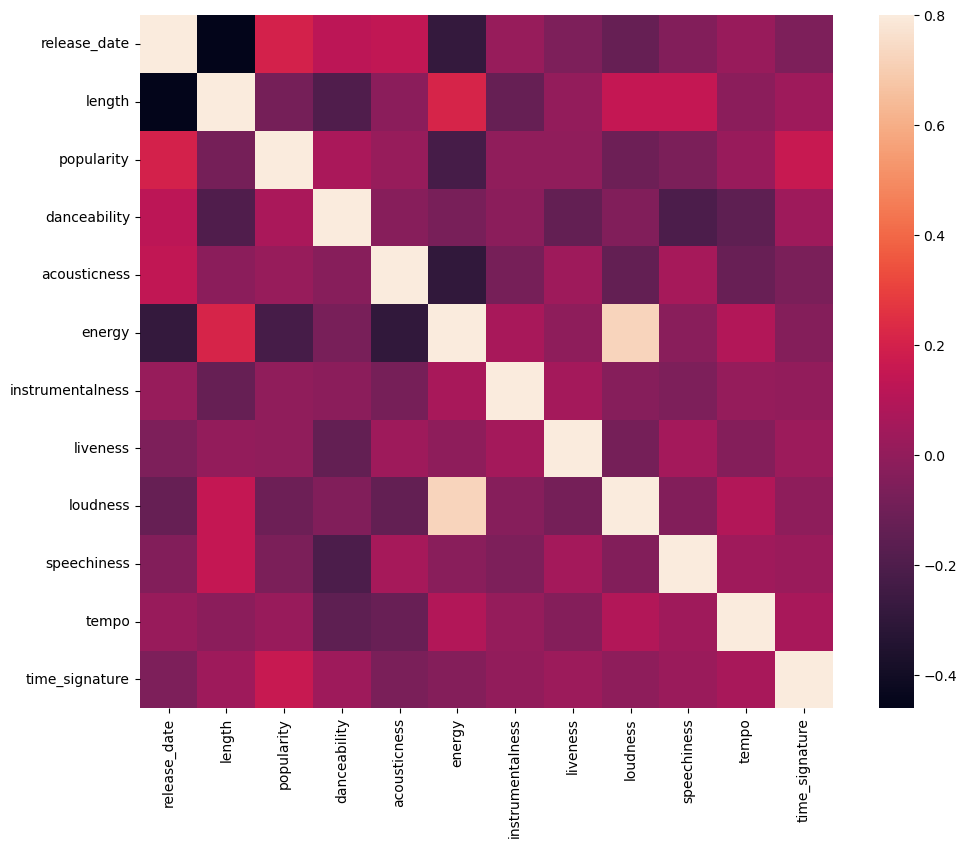

In [18]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

Are these three genres significantly different in the perception of their danceability, based on their popularity?

## Data distribution

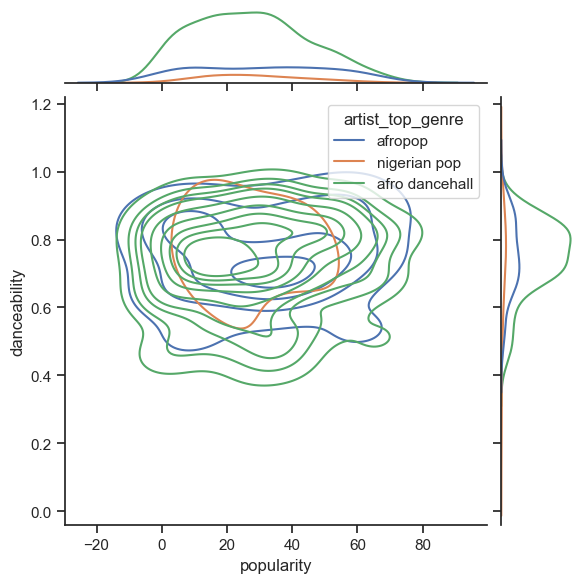

In [19]:
sns.set_theme(style="ticks")

g = sns.jointplot(
    data=df,
    x="popularity", y="danceability", hue="artist_top_genre",
    kind="kde",
)

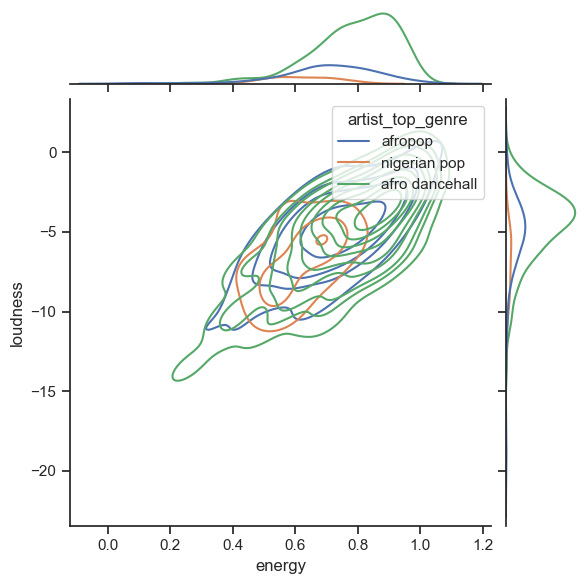

In [21]:
sns.set_theme(style="ticks")

g = sns.jointplot(
    data=df,
    x="energy", y="loudness", hue="artist_top_genre",
    kind="kde",
)

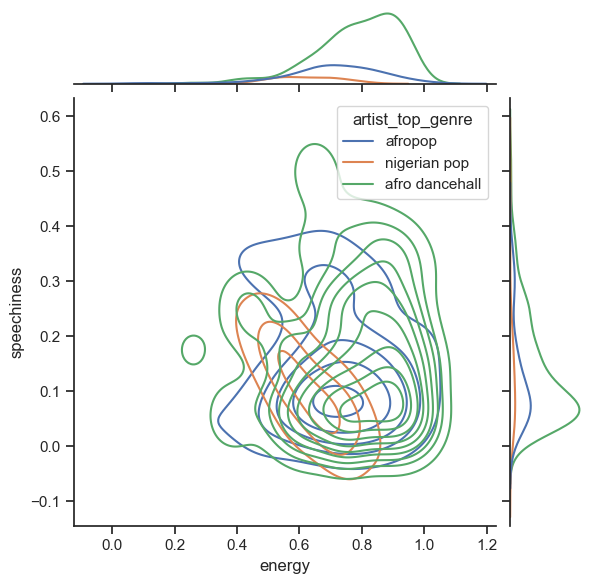

In [22]:
sns.set_theme(style="ticks")

g = sns.jointplot(
    data=df,
    x="energy", y="speechiness", hue="artist_top_genre",
    kind="kde",
)

c:\Users\clayton jhordan\.conda\envs\Clayton_Jhordan\lib\site-packages\seaborn\axisgrid.py:337: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


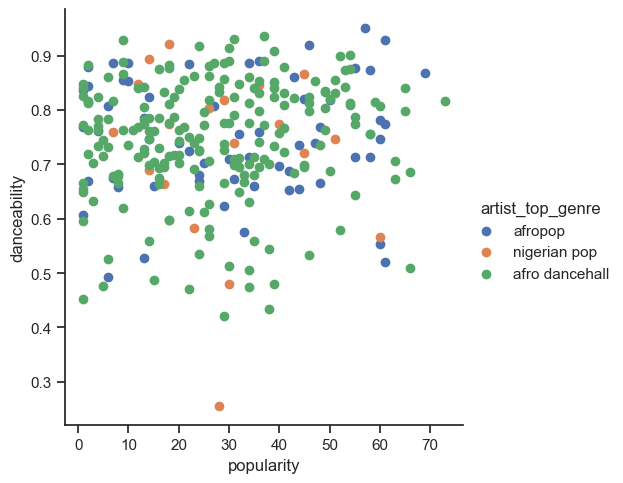

In [23]:
sns.FacetGrid(df, hue="artist_top_genre", size=5) \
   .map(plt.scatter, "popularity", "danceability") \
   .add_legend()

# K-Means Clustering

<AxesSubplot:xlabel='release_date'>

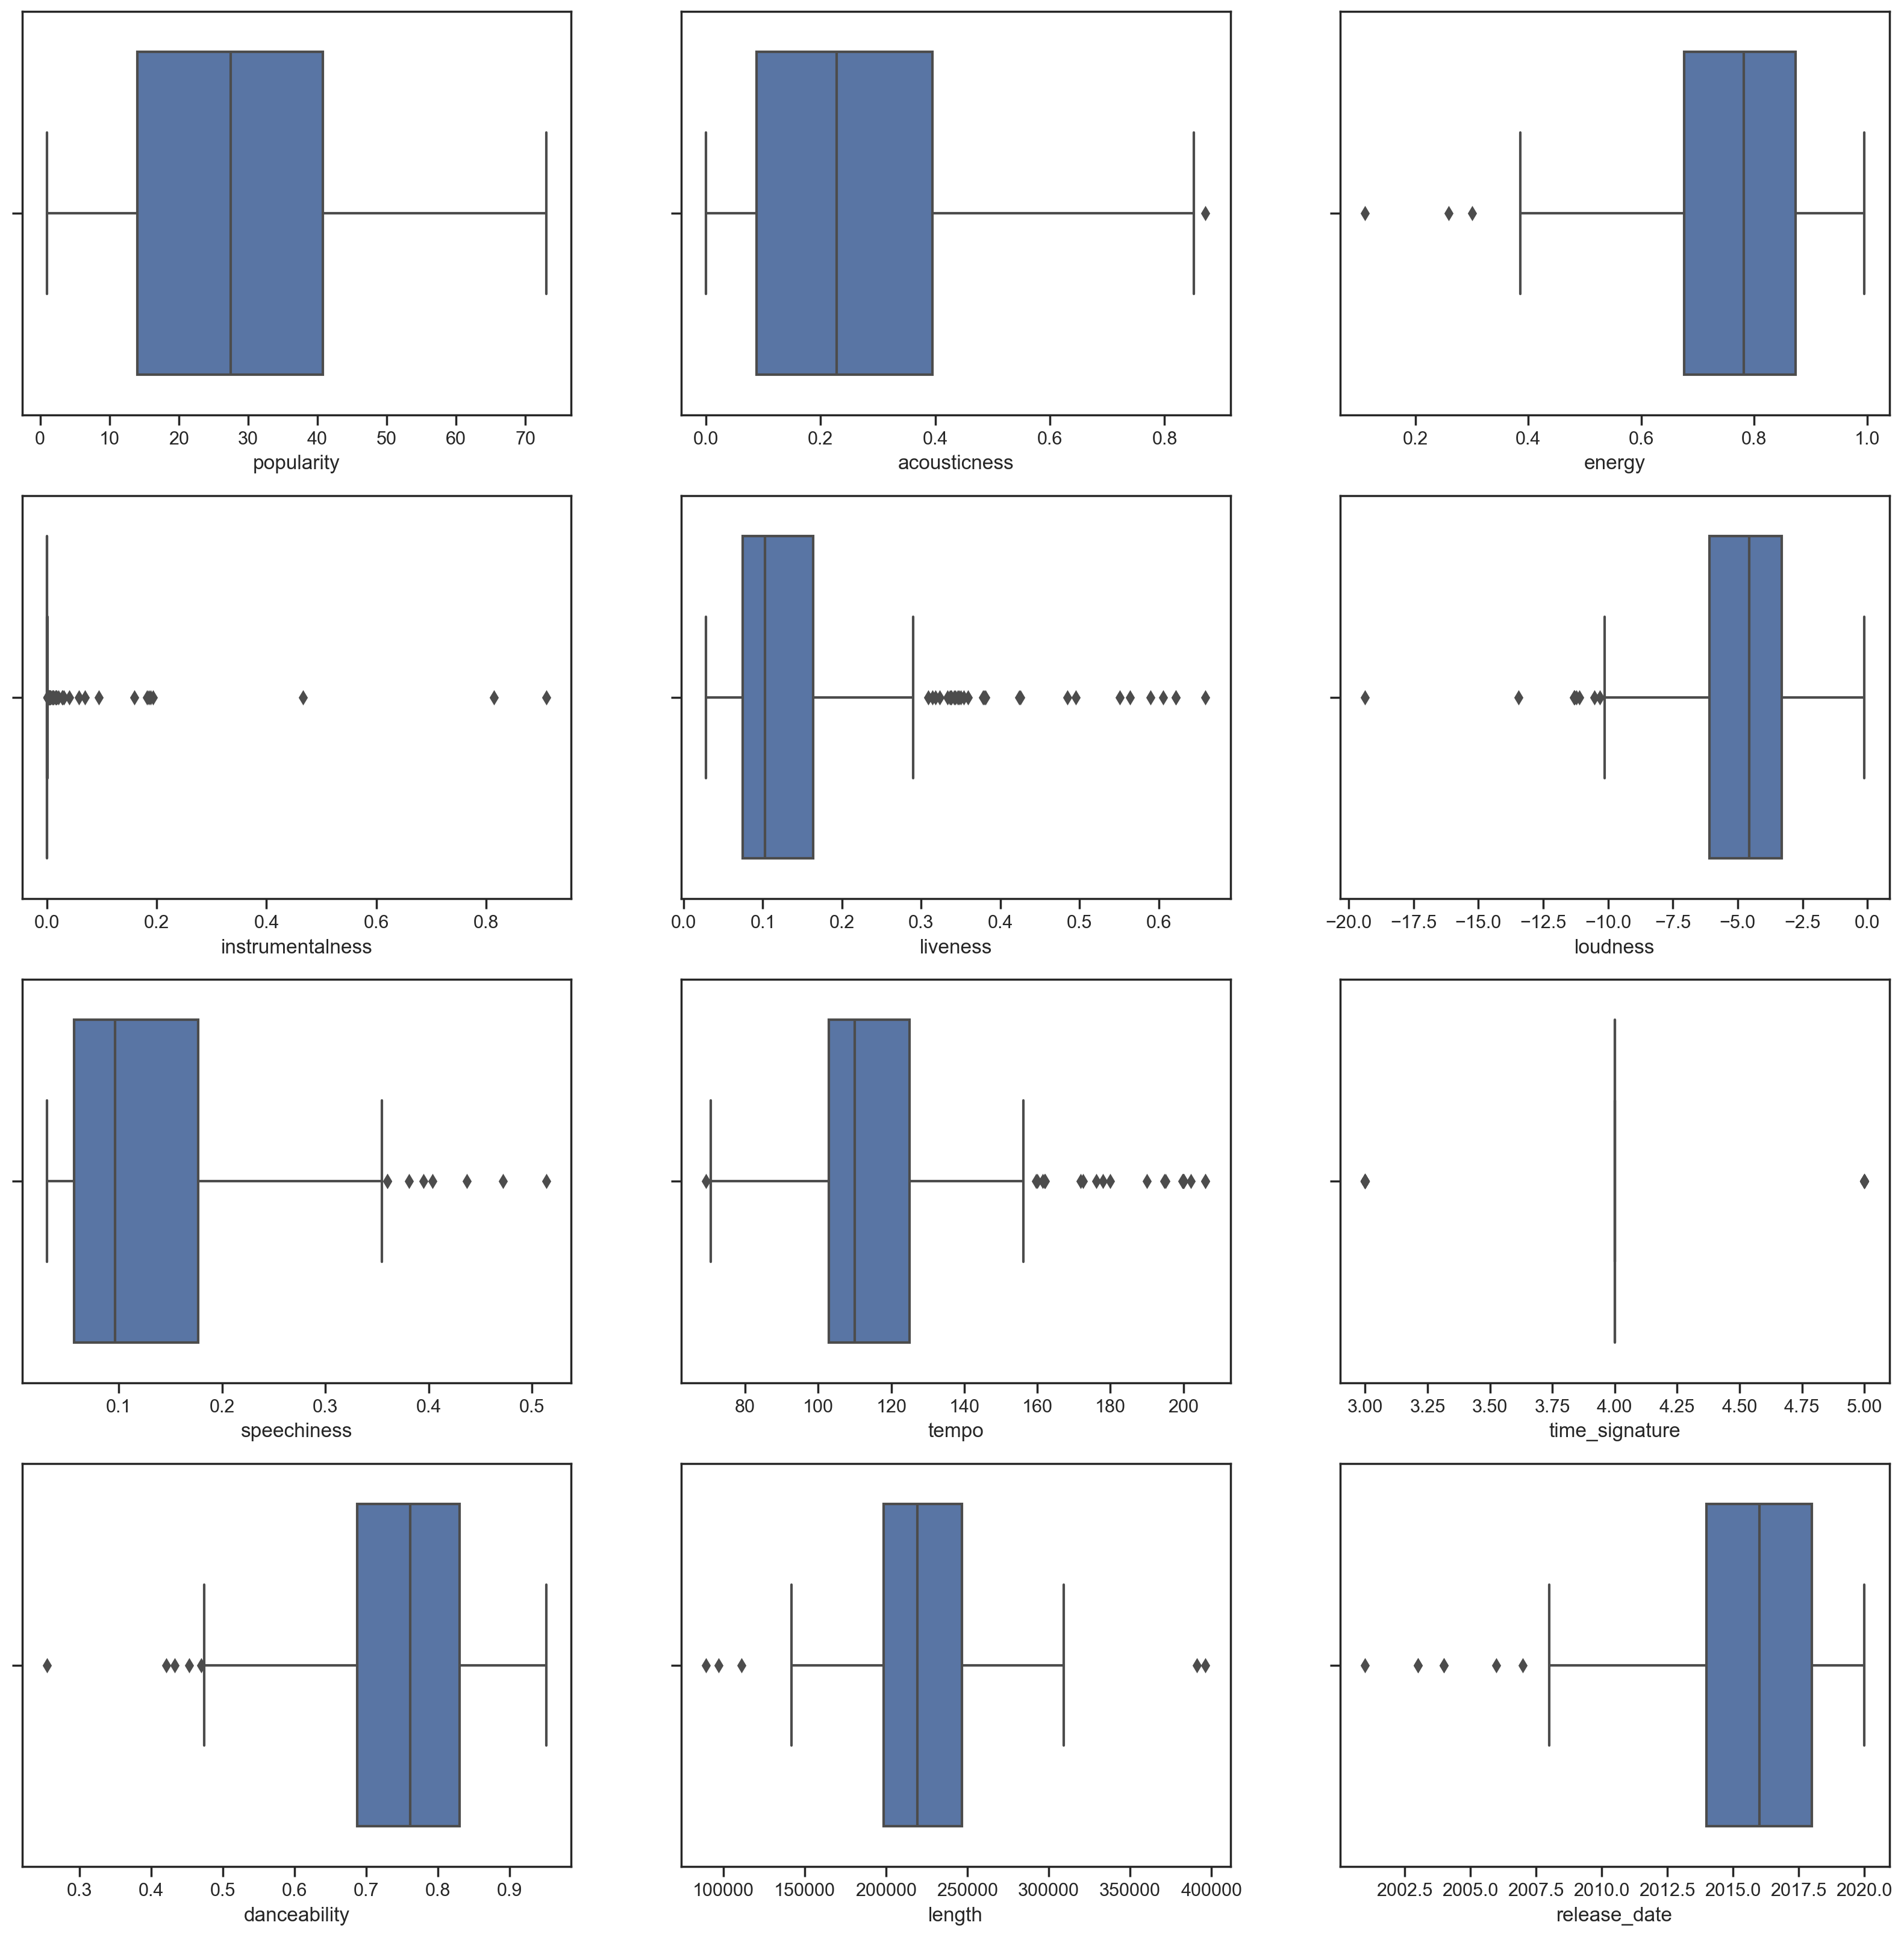

In [24]:
plt.figure(figsize=(20,20), dpi=200)

plt.subplot(4,3,1)
sns.boxplot(x = 'popularity', data = df)

plt.subplot(4,3,2)
sns.boxplot(x = 'acousticness', data = df)

plt.subplot(4,3,3)
sns.boxplot(x = 'energy', data = df)

plt.subplot(4,3,4)
sns.boxplot(x = 'instrumentalness', data = df)

plt.subplot(4,3,5)
sns.boxplot(x = 'liveness', data = df)

plt.subplot(4,3,6)
sns.boxplot(x = 'loudness', data = df)

plt.subplot(4,3,7)
sns.boxplot(x = 'speechiness', data = df)

plt.subplot(4,3,8)
sns.boxplot(x = 'tempo', data = df)

plt.subplot(4,3,9)
sns.boxplot(x = 'time_signature', data = df)

plt.subplot(4,3,10)
sns.boxplot(x = 'danceability', data = df)

plt.subplot(4,3,11)
sns.boxplot(x = 'length', data = df)

plt.subplot(4,3,12)
sns.boxplot(x = 'release_date', data = df)

For now, we don't remove the outliers, because our data set turn into a small dataset.

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [147]:
X = df.loc[:, ('artist_top_genre','popularity','danceability','acousticness','loudness','energy')]
X

,artist_top_genre,popularity,danceability,acousticness,loudness,energy
1,afropop,30,0.710,0.0822,-5.640,0.683
3,nigerian pop,14,0.894,0.7980,-4.961,0.611
4,afropop,25,0.702,0.1160,-6.044,0.833
5,nigerian pop,26,0.803,0.1270,-10.034,0.525
6,nigerian pop,29,0.818,0.4520,-9.840,0.587
...,...,...,...,...,...,...
514,afro dancehall,20,0.838,0.0358,-3.723,0.931
515,afro dancehall,14,0.786,0.1950,-4.232,0.806
519,afropop,2,0.879,0.2240,-4.602,0.916
522,afro dancehall,26,0.863,0.0366,-3.130,0.896


In [148]:
y = df['artist_top_genre']
y 

1             afropop
3        nigerian pop
4             afropop
5        nigerian pop
6        nigerian pop
            ...      
514    afro dancehall
515    afro dancehall
519           afropop
522    afro dancehall
525    afro dancehall
Name: artist_top_genre, Length: 286, dtype: object

In [149]:
X['artist_top_genre'] = le.fit_transform(X['artist_top_genre'])
X 


,artist_top_genre,popularity,danceability,acousticness,loudness,energy
1,1,30,0.710,0.0822,-5.640,0.683
3,2,14,0.894,0.7980,-4.961,0.611
4,1,25,0.702,0.1160,-6.044,0.833
5,2,26,0.803,0.1270,-10.034,0.525
6,2,29,0.818,0.4520,-9.840,0.587
...,...,...,...,...,...,...
514,0,20,0.838,0.0358,-3.723,0.931
515,0,14,0.786,0.1950,-4.232,0.806
519,1,2,0.879,0.2240,-4.602,0.916
522,0,26,0.863,0.0366,-3.130,0.896


In [150]:
y = le.transform(y)
y

array([1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 2, 1, 0, 2, 2, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

# Appling K-Means

In [103]:
from sklearn.cluster import KMeans

nclusters = 3 
seed = 0

km = KMeans(n_clusters=nclusters, random_state=seed)
km.fit(X)

# Predict the cluster for each data point

y_cluster_kmeans = km.predict(X)
y_cluster_kmeans

array([2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 2, 1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 2, 1,
       2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2,
       0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1,
       0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2,
       0, 2, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 0, 1, 0, 2, 2,
       2, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 1,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2,
       0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0])

## Silhouette Score

Look for a silhouette score closer to 1. This score varies from -1 to 1, and if the score is 1, the cluster is dense and well-separated from other clusters. A value near 0 represents overlapping clusters with samples very close to the decision boundary of the neighboring clusters. (Source)

Our score is .53, so right in the middle. This indicates that our data is not particularly well-suited to this type of clustering, but let's continue.

In [104]:
from sklearn import metrics
score = metrics.silhouette_score(X, y_cluster_kmeans)
score

0.5466747351275563

## Build the model

We try kluster from c = 1 to C = 11, init = 'k-means++' selects initial cluster centroids using sampling based on an empirical probability distribution of the points’ contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is “greedy k-means++”. It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.

WCSS: "within-cluster sums of squares" measures the squared average distance of all the points within a cluster to the cluster centroid.

Inertia: K-Means algorithms attempt to choose centroids to minimize 'inertia', "a measure of how internally coherent clusters are." Source. The value is appended to the wcss variable on each iteration.

In [105]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


In [106]:
wcss

[91386.6567935086,
 28634.205205937666,
 13100.549391531438,
 8690.96299754289,
 6003.210058960905,
 4619.742563224037,
 3988.205131011303,
 3545.064713255375,
 3286.8611110542565,
 3043.2626421547775]

## Elbow method

c:\Users\clayton jhordan\.conda\envs\Clayton_Jhordan\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


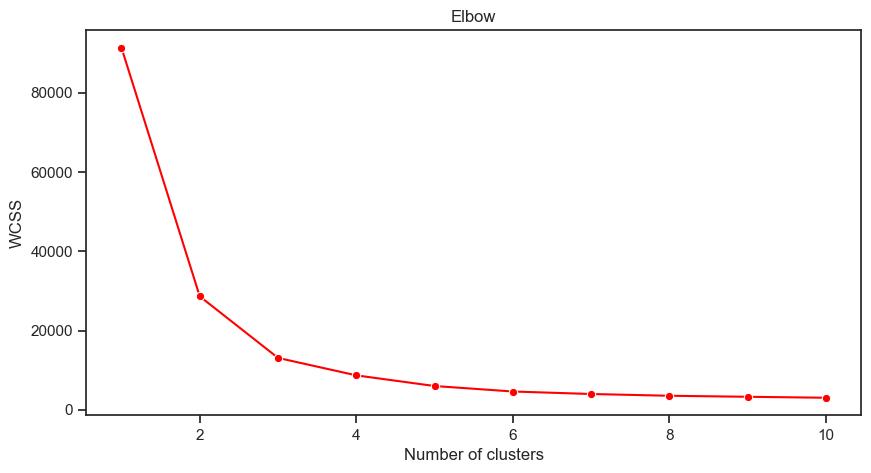

In [38]:
plt.figure(figsize=(10,5))

sns.lineplot(range(1, 11), wcss,marker='o',color='red')


plt.title('Elbow')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Use the wcss variable that you built in the previous step to create a chart showing where the 'bend' in the elbow is, which indicates the optimum number of clusters. Maybe it is 3!

# Display clusters

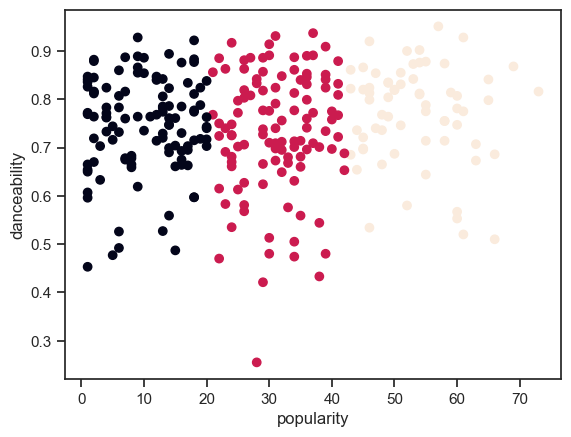

In [108]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3, random_state= 42)
kmeans.fit(X)
labels = kmeans.predict(X)


plt.scatter(df['popularity'],df['danceability'],c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [109]:
labels = kmeans.labels_

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 105 out of 286 samples were correctly labeled.
Accuracy score: 0.37


This model's accuracy is not very good, and the shape of the clusters gives you a hint why.

This data is too imbalanced, too little correlated and there is too much variance between the column values to cluster well. In fact, the clusters that form are probably heavily influenced or skewed by the three genre categories we defined above. That was a learning process!

# Scaling the Data

In [151]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [112]:
X.popularity = scaler.fit_transform(X.popularity.values.reshape(-1,1))

In [152]:
X

,artist_top_genre,popularity,danceability,acousticness,loudness,energy
1,1,30,0.710,0.0822,-5.640,0.683
3,2,14,0.894,0.7980,-4.961,0.611
4,1,25,0.702,0.1160,-6.044,0.833
5,2,26,0.803,0.1270,-10.034,0.525
6,2,29,0.818,0.4520,-9.840,0.587
...,...,...,...,...,...,...
514,0,20,0.838,0.0358,-3.723,0.931
515,0,14,0.786,0.1950,-4.232,0.806
519,1,2,0.879,0.2240,-4.602,0.916
522,0,26,0.863,0.0366,-3.130,0.896


In [156]:
X_minmax = pd.DataFrame()

In [157]:
# Seleccionar las columnas a escalar
columns_to_scale = ['popularity', 'danceability','acousticness','loudness','energy']

# Escalar las columnas seleccionadas
scaled_values = scaler.fit_transform(X[columns_to_scale])

# Crear nuevas columnas escaladas en el DataFrame original
for i, col in enumerate(columns_to_scale):
    X_minmax[col + '_scaled'] = scaled_values[:, i]

print(X_minmax)

     popularity_scaled  danceability_scaled  acousticness_scaled  \
0             0.402778             0.653736             0.093682   
1             0.180556             0.918103             0.916124   
2             0.333333             0.642241             0.132518   
3             0.347222             0.787356             0.145157   
4             0.388889             0.808908             0.518576   
..                 ...                  ...                  ...   
281           0.263889             0.837644             0.040370   
282           0.180556             0.762931             0.223288   
283           0.013889             0.896552             0.256608   
284           0.347222             0.873563             0.041289   
285           0.125000             0.689655             0.725393   

     loudness_scaled  energy_scaled  
0           0.712979       0.647059  
1           0.748259       0.565611  
2           0.691988       0.816742  
3           0.484672       0.46

In [158]:
X_minmax['artist_top_genere'] = X.reset_index()['artist_top_genre']

In [161]:
X_minmax

,popularity_scaled,danceability_scaled,acousticness_scaled,loudness_scaled,energy_scaled,artist_top_genere
0,0.402778,0.653736,0.093682,0.712979,0.647059,1
1,0.180556,0.918103,0.916124,0.748259,0.565611,2
2,0.333333,0.642241,0.132518,0.691988,0.816742,1
3,0.347222,0.787356,0.145157,0.484672,0.468326,2
4,0.388889,0.808908,0.518576,0.494752,0.538462,2
...,...,...,...,...,...,...
281,0.263889,0.837644,0.040370,0.812584,0.927602,0
282,0.180556,0.762931,0.223288,0.786137,0.786199,0
283,0.013889,0.896552,0.256608,0.766913,0.910633,1
284,0.347222,0.873563,0.041289,0.843396,0.888009,0


In [77]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()

In [116]:
X.loudness = st_scaler.fit_transform(X.loudness.values.reshape(-1,1))

## MIN-MAX POPULARITY

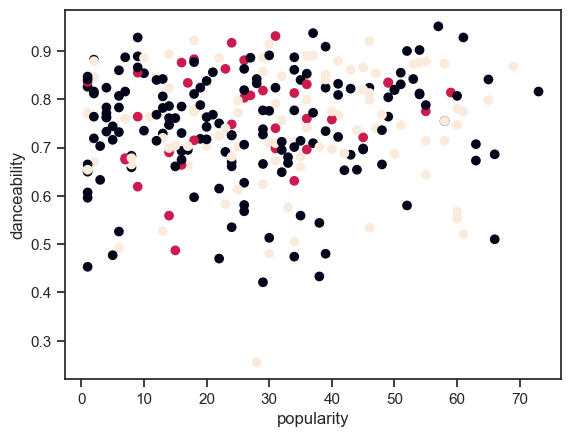

In [117]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3, random_state= 42)
kmeans.fit(X)
labels = kmeans.predict(X)


plt.scatter(df['popularity'],df['danceability'],c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [118]:
labels = kmeans.labels_

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

from sklearn import metrics
score = metrics.silhouette_score(X, labels)
print(f'Silhoute  score is :{score}')

Result: 157 out of 286 samples were correctly labeled.
Accuracy score: 0.55
Silhoute  score is :0.32618997416384216


## MIN_MAX ALLL THE VALUES

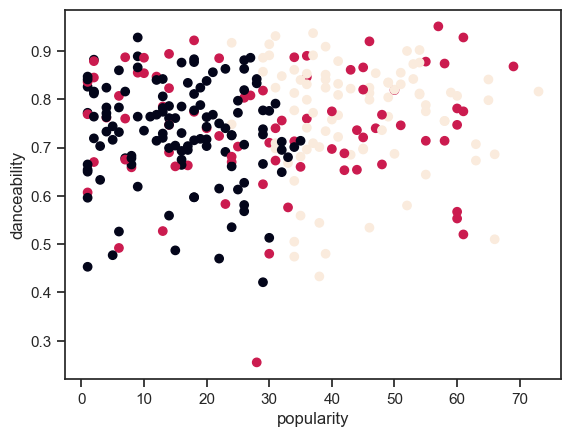

In [162]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3, random_state= 42)
kmeans.fit(X_minmax)
labels = kmeans.predict(X_minmax)


plt.scatter(df['popularity'],df['danceability'],c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [163]:
labels = kmeans.labels_

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

from sklearn import metrics
score = metrics.silhouette_score(X, labels)
print(f'Silhoute  score is :{score}')

Result: 182 out of 286 samples were correctly labeled.
Accuracy score: 0.64
Silhoute  score is :0.1675780001750343
